# ENGR 1451/2451 — Weekly Assignment 1
**10 points**

This assignment focuses on four goals: basic Python expressions, working with a `pandas` DataFrame, calculating summary statistics, and visualizing data.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested. Submit the completed notebook as directed in Canvas.

## What to hand in

Work this assignment with the **course tutor** in the class project. That is the AI help to use on this assignment, and it keeps the record for you — you do not write one yourself.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To pick up later, start a new chat in the same project, say which assignment you are on and which problem you stopped at, and keep going. That session gives you its own block, which you paste under the previous one.

Records are not graded for correctness or for how much help you needed, and extra credit is given for a record that shows you attempted the problem. The code and the written answers still have to be yours.

## LE1-1. Python warm-up (1 pt)
Use Python as a calculator. In one code cell, show an example of:
- addition,
- subtraction,
- multiplication,
- division, and
- exponentiation.

In [ ]:
add = 1+1
subtract = 1-2
mult = 1*4
divis = 6/3
expon = 2 ** 4
print("1 + 1 =", add, 
      "| 1 - 2 =", subtract, 
      "| 1 * 4 =", mult,
      "| 6/3 =", divis,
     "| 2^4 =", expon)

1 + 1 = 2 | 1 - 2 = -1 | 1 * 4 = 4 | 6/3 = 2.0 | 2^4 = 16


## LE1-2. Iris data: structure, summary statistics, and visualization (6 pts)

A useful data-analysis workflow can be summarized as:
**question → data → cleaning → exploratory analysis → visualization → interpretation → communication → reproducible code**.

For this exercise, use the `iris.csv` file supplied with this assignment. Download it from Canvas and put it in a folder named `data` next to this notebook, so that the path `./data/iris.csv` works. The file contains measurements of sepal length/width and petal length/width for three iris species.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

iris = pd.read_csv("./data/iris.csv")
iris = iris.drop(columns=["rownames"], errors="ignore")
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### A. Understand the data (2 pts)
Using Python, answer:
1. How many observations (rows) are in the dataset?
2. Which variables are numerical? Are they continuous or discrete?
3. Which variable is categorical, and what are its categories?
4. How many observations belong to each species?

**Answer:**

In [ ]:
# Useful tools: iris.shape, iris.dtypes, iris.select_dtypes(),
# iris["Species"].unique(), iris["Species"].value_counts()

# Your code here
#1
print("#1")
rows,cols = iris.shape #getting dimmensions
print("There are", rows, "rows in the dataset.")

#2
print("\n#2")
numeric_col_names = iris.select_dtypes(include="number").columns.tolist() #creating a list of names
continuous_col_names = iris.select_dtypes(float).columns.tolist() #continuous vars (unless if whole numbers are reported as 3.0000--i.e. with unneded decimal places)
discrete_col_names = iris.select_dtypes(int).columns.tolist() #discrete vars

print("The following variables are numerical: ", ", ".join(numeric_col_names),
      "\nContinuous variables:", ", ".join(continuous_col_names), "\nDiscrete variables:", ", ".join(discrete_col_names))

#3
print("\n#3")
categorical_col_name = iris.select_dtypes(include="object").columns.tolist() #getting the name of the categorical variable column in list form
#pandas uses object for .csv files, strings reference a pandas construct in the include="__" 
categorical_col_var_names = iris[categorical_col_name[0]].unique() #[0] is used because string needs to be extraced from the list
print("".join(categorical_col_name), "is the categorical variable in this data frame. It has the following categories: ",", ".join(categorical_col_var_names))

#4
print("\n#4")
print("The species and respective number of observations are as follows: ")
print(iris[categorical_col_name[0]].value_counts()) #value counts displays the counts for each catergorical variable

      

#1
There are 150 rows in the dataset.

#2
The following variables are numerical:  Sepal.Length, Sepal.Width, Petal.Length, Petal.Width 
Continuous variables: Sepal.Length, Sepal.Width, Petal.Length, Petal.Width 
Discrete variables: 

#3
Species is the categorical variable in this data frame. It has the following categories:  setosa, versicolor, virginica

#4
The species and respective number of observations are as follows: 
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


C:\Users\julia\AppData\Local\Temp\ipykernel_2052\1748002819.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col_name = iris.select_dtypes(include="object").columns.tolist() #getting the name of the categorical variable column in list form


### B. Analyze *versicolor* (2 pts)
1. Create a DataFrame containing only `versicolor` flowers.
2. Report the mean and median of each numerical variable.
3. Briefly explain why a single overall mean for all three species can be misleading.

**Answer:**

In [ ]:
# Your code here
#1
print("#1")
numeric_column_titles = iris.select_dtypes(include="number").columns

versicolor = iris.loc[
    iris["Species"] == "versicolor",
    numeric_column_titles,
] #isolates specified rows with variety Veriscolor

print(versicolor.head())

#2
print("\n#2")
v_mean_mid = versicolor.agg(['mean','median'])
print("Versicolor species measures of center\n",v_mean_mid)

#3
print("\n#3\nA single overall mean for all three species can be misleading because it neglects to account for",
"the fact that each species may tend to have longer/shorter petals or sepals than other species. "
"The mean fails to capture any difference in values between species since it incorporates all of the data across the species and does not display"
" any data specific to one of the species." )

#1
    Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
50           7.0          3.2           4.7          1.4
51           6.4          3.2           4.5          1.5
52           6.9          3.1           4.9          1.5
53           5.5          2.3           4.0          1.3
54           6.5          2.8           4.6          1.5

#2
Versicolor species measures of center
         Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
mean           5.936         2.77          4.26        1.326
median         5.900         2.80          4.35        1.300

#3
A single overall mean for all three species can be misleading because it neglects to account for the fact that each species may tend to have longer/shorter petals or sepals than other species. The mean fails to capture any difference in values since it incorporates all of the data across the species and does not display any data specific to one of the species.


### C. Visualize the iris data (2 pts)
Create a scatter plot of **Petal.Length** versus **Petal.Width** for all flowers in the iris dataset.

1. Put `Petal.Width` on the x-axis and `Petal.Length` on the y-axis.
2. Color the points by species so the three species can be compared.
3. Label both axes and include a legend.
4. Briefly describe the main pattern you see in the plot.

**Answer:**

Observations about main pattern: petal length and petal width appear to have a moderate-stong, positive, and linear correlation. Setosa irises from this dataset have noticeably smaller petals and sepals than versicolor or virginica irises. Virginica irises have slightly larger petals and sepals than versicolor irises in this dataset.


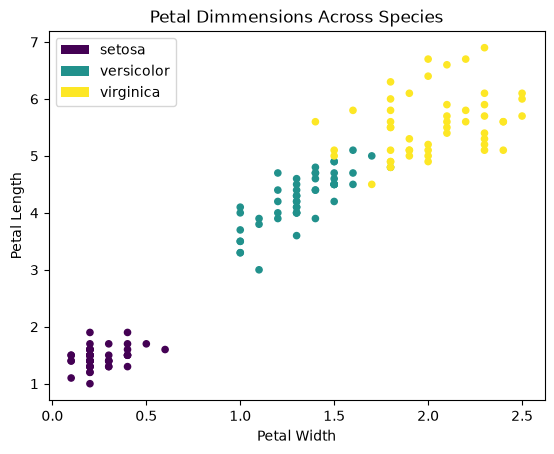

In [ ]:
# Your visualization code here
ax = iris.plot.scatter(x="Petal.Width",y="Petal.Length",c="Species") #c represents the gradient variable, autogenerates colors and legend
ax.set_xlabel("Petal Width")
ax.set_ylabel("Petal Length")
ax.set_title("Petal Dimmensions Across Species")

print("Observations about main pattern: petal length and petal width appear to have a moderate-stong, positive, and linear correlation.",
"Setosa irises from this dataset have noticeably smaller petals and sepals than versicolor or virginica irises. Virginica irises have slightly",
"larger petals and sepals than versicolor irises in this dataset.")

## LE1-3. Distribution shape and appropriate statistics (3 pts)

For each situation, state:
1. expected shape: **symmetric, right-skewed, or left-skewed**;
2. better measure of center: **mean or median**;
3. better measure of spread: **standard deviation or IQR**;
4. a brief reason.

Each case is worth 0.75 pt.

| Case | Situation |
|---|---|
| **a** | House prices: Q1 = \$350k, median = \$450k, Q3 = \$1.0M, with a meaningful number above \$6M |
| **b** | House prices: Q1 = \$300k, median = \$600k, Q3 = \$900k, with very few above \$1.2M |
| **c** | Weekly alcoholic drinks among students: most consume 0, while a few consume many |
| **d** | Scores on a straightforward 100-point quiz: most students score in the 80s and 90s, with a few much lower scores |

# **Answers:**

(for 4., reasoning is included in parts 1-3)
## a. 
    1. Right-skewed, larger delta between median and Q3 (as opposed to Q1 and median) + meaningful number of high price (>6M) outliers indicates that there will be a significant skew towards the right/upper end of house prices.
    2. Given the prescence of high outliers and noticeable skew, the median will be a better measure of central tendency than the mean. The median is more resistant to outliers than the mean.
    3. Just like the median, the IQR is more resistant to outliers and skew than the standard deviation, so it will likley be the better measure of spread in this case.

## b.
    1. Symmetric, the delta between the median and Q1/Q2 is identical and there are very few high outliers, which points towards a symmetric shape.
    2. Since the data is symmetric and has few outliers, the mean would likley be the best measure of central tendency in this case. 
    3. Just like the mean, since the data is symmetric and has few outliers, the standard deviation would likley be the best measure of central tendency in this case.
    4. To add onto 2. & 3., the median and IQR are based on rank, whereas the mean and standard deviation take into account every data point. In this case, the data is symmetric and has few outliers, so the mean and standard deviation will provide a slightly more representative measure of central tendency and spread than the median and IQR. 
    
## c.
    1. Right-skewed, most of the data (weekly alcoholic drinks among students) is concentrated around 0, while a few outliers consume a larger amount of alcoholic drinks.
    2. (same explanation as 2 & 3 from part a.) Given the prescence of outliers and noticeable righ-skew, the median will be a better measure of central tendency than the mean. The median is more resistant to outliers than the mean.
    3. (same explanation as 2 & 3 from part a.)Just like the median, the IQR is more resistant to outliers and skew than the standard deviation, so it will likley be the better measure of spread in this case.
    
## d. 
    1. Left-skewed, most of the data is concentrated around higher scores, but a few outliers score very low.
    2. (same explanation as 2 & 3 from part a.) Given the prescence of outliers and noticeable left-skew, the median will be a better measure of central tendency than the mean. The median is more resistant to outliers than the mean.
    3. (same explanation as 2 & 3 from part a.) Just like the median, the IQR is more resistant to outliers and skew than the standard deviation, so it will likley be the better measure of spread in this case.

In [ ]:
## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

Assignments are not graded for correctness or for how much help you needed, and extra credit is given for a record that shows you attempted the problem. They are read to find out which steps are hardest, and used to improve the course.

<!-- Paste your session record blocks in this cell, one after another. -->
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "LE01",
  "export_n": 1,
  "session_date": "2026-08-29",
  "messages": [
    {"i": 1, "who": "student", "text": "Hello! I am starting LEO1."},
    {"i": 2, "who": "tutor", "served": ["how_to_use", "a1_preamble", "a1_le1_1"]},
    {"i": 3, "who": "student", "text": "Is exp() the exponentiation command in python?"},
    {"i": 4, "who": "tutor", "text": "exp() is not the exponentiation operator... math.exp(x) computes e**x. The operator for exponentiation in Python is **, e.g. 2 ** 3 gives 8. Note ^ is bitwise XOR in Python, not exponentiation. [trimmed] Want me to say more about ** with negative or fractional exponents, or are you set to write your cell?"},
    {"i": 5, "who": "student", "text": "Understood"},
    {"i": 6, "who": "tutor", "text": "Good — sounds like you're ready. Go ahead and write your cell with all five operators whenever you want, and paste it here if you'd like a look, or just move on to LE1-2 when you're set."},
    {"i": 7, "who": "student", "text": "How can I express strings and numeric variables with the print command?"},
    {"i": 8, "who": "tutor", "text": "print() takes one or more things separated by commas... [trimmed examples of printing strings, numbers, mixing text and numbers with commas, and labeling results like print(\"Sum:\", a + b)] ...also f-strings, e.g. print(f\"Sum: {a + b}\"). Want me to go further into f-strings, or are you good to write your LE1-1 cell now?"},
    {"i": 9, "who": "student", "text": "Is ... the command for continuing a long string?"},
    {"i": 10, "who": "tutor", "text": "... is not how Python continues a string across lines; it's the Ellipsis object, unrelated to strings. [trimmed — explained backslash line continuation, implicit continuation inside parentheses, and adjacent string literal joining, with examples] For something as short as your LE1-1 line you probably won't need any of this. Want me to go further, or are you set?"},
    {"i": 11, "who": "student", "text": "Got it"},
    {"i": 12, "who": "tutor", "text": "Sounds good — go ahead and write your LE1-1 cell whenever you're ready. Paste it here if you want a look, or let me know when you're moving on to LE1-2."},
    {"i": 13, "who": "student", "text": "Does one code cell mean including every desired operation in the markdown cell or everything in one line of code?"},
    {"i": 14, "who": "tutor", "text": "\"One code cell\" refers to the code cell, not the markdown cell above it. Within that one cell you don't need everything on one line — five separate print() lines, one per operation, is the natural way. [trimmed example] Does that clear it up, or is something still fuzzy?"},
    {"i": 15, "who": "student", "text": "How can I install pandas on jupyter? I have it installed on my computer, but do I need to install it in the terminal on the Unix teaching cluster?"},
    {"i": 16, "who": "tutor", "text": "Having pandas locally doesn't help if the kernel runs on the cluster — that's a separate machine. [trimmed — check with import pandas as pd; print(pd.__version__), then pip install pandas --user on a cluster terminal if missing, then confirm the notebook's kernel matches the environment where it was installed] If you hit a specific error, paste it here."},
    {"i": 17, "who": "student", "text": "I accidentally ran pip install panda, how can I delete the panda library from the teaching cluster?"},
    {"i": 18, "who": "tutor", "text": "That installed an unrelated package named panda, not pandas. Run pip uninstall panda (or pip uninstall panda -y to skip confirmation) in a cluster terminal session. Won't affect pandas at all. Let me know if the uninstall throws anything unexpected."},
    {"i": 19, "who": "student", "text": "Cool, that worked"},
    {"i": 20, "who": "tutor", "text": "Great, glad that's sorted. Go ahead and get pandas installed and imported whenever you're ready, and let me know how LE1-1 or LE1-2 is going."},
    {"i": 21, "who": "student", "text": "Will (row,col) = iris.shape save the row and column numbers in the row and col variables?"},
    {"i": 22, "who": "tutor", "text": "Yes — .shape returns a tuple like (150, 5), and Python supports tuple unpacking, so row, col = iris.shape assigns row=150, col=5 by position. Parentheses are optional. Number of variables must match the tuple length or you get a ValueError. [trimmed generic example] Does that make sense, or do you want to see what happens with a longer tuple?"},
    {"i": 23, "who": "student", "text": "Nice, can you run over what this code is doing and how I could recreate it in future data tasks? \niris = iris.drop(columns=[\"rownames\"], errors=\"ignore\")\niris.head()", "code": true},
    {"i": 24, "who": "tutor", "text": ".drop() removes rows or columns; columns= targets column(s), passed as a list even for one column. It returns a new DataFrame rather than modifying in place, which is why the line reassigns iris. errors=\"ignore\" prevents a KeyError if the column isn't there. .head() returns the first 5 rows by default, a quick sanity check. [trimmed generic example on a made-up df] This drop(columns=[...], errors=\"ignore\") pattern is a solid default for safely dropping a column that might already be gone. Want me to go over .tail() or .sample() too?"},
    {"i": 25, "who": "student", "text": "Can you help visualize this more for me?"},
    {"i": 26, "who": "tutor", "text": "The left box is df before the drop — three columns, three rows. The id column gets dropped, and what comes out the other side is a new DataFrame with only name and score. The original df reference is reassigned to point at that new, smaller frame — nothing is modified in place. Then .head() on the result just returns its first rows for a quick look. Same shape you'd use for iris, just with rownames in place of id. Want to look at anything else before moving on?"},
    {"i": 27, "who": "student", "text": "Can you explain the difference between discrete and continuous variables?"},
    {"i": 28, "who": "tutor", "text": "Discrete variables take separate, countable values with gaps between them — number of siblings, petal count. Continuous variables can take any value in a range, limited only by measurement precision — height, weight, time. Test: if there's an infinite number of possible values between two nearby measurements, it's continuous. A wrinkle: a column stored with a fixed number of decimals doesn't by itself tell you discrete vs continuous — that's about what's being measured, not how it's rounded for display. Does that distinction feel solid, or want to try classifying a few examples together first?"},
    {"i": 29, "who": "student", "text": "That makes sense"},
    {"i": 30, "who": "tutor", "text": "Good — sounds like you've got the concept down. Whenever you're ready, go ahead and apply it to iris's numerical columns for LE1-2A, and let me know how it goes or if anything else comes up."},
    {"i": 31, "who": "student", "text": "Which command can I use to identify numeric variables? I am thinking I could use iris.select_dtypes() to manually select int, float, and double, but I was wondering if there was a more efficient way of achieving the same goal."},
    {"i": 32, "who": "tutor", "text": "select_dtypes() takes include=, and you can pass the general category \"number\" instead of listing every specific numeric type: df.select_dtypes(include=\"number\"). [trimmed generic example] include=\"object\" or exclude=\"number\" gets the complement; .columns on the result gives just the names. Want to see exclude= too, or are you set to use this on iris?"},
    {"i": 33, "who": "student", "text": "What does include= do in python?"},
    {"i": 34, "who": "tutor", "text": "include= isn't a general Python keyword, it's a parameter name defined by select_dtypes() specifically. For select_dtypes() it tells the method which column types to keep — a string like \"number\", a list of types, or an actual type like int. [trimmed generic example with a greet(name, greeting=\"Hello\") function showing named parameters] Does that clear it up, or do you want to look at exclude= too?"},
    {"i": 35, "who": "student", "text": "Is there a command I can use to extract the titles of the rows of the numeric variables and store them as a list of string variables?"},
    {"i": 36, "who": "tutor", "text": "df.select_dtypes(include=\"number\").columns.tolist() — .columns gives a pandas Index, .tolist() converts it to a plain Python list. [trimmed generic example] Note: \"titles of the rows\" isn't quite right terminology — these are column names, not row titles; rows are usually just numbered by index. Does that distinction make sense, or want to see how row indices work too?"},
    {"i": 37, "who": "student", "text": "Could I use cont_vars_col_names = iris.select_dtypes(float).columns.tolist to identifiy continuous variables in the dataset?", "code": true},
    {"i": 38, "who": "tutor", "text": "select_dtypes(float) works fine positionally, but .tolist is missing its parentheses — without () you're referencing the method itself, not calling it. Fix: iris.select_dtypes(float).columns.tolist(). Separately: dtype and continuous-vs-discrete aren't strictly the same thing in general — a discrete variable could be stored as float, and vice versa — worth checking dtype against what's actually being measured for iris specifically. Want to check iris.dtypes side by side with what each column measures before committing to that list?"},
    {"i": 39, "who": "student", "text": "Will python return an error if it does not find any float variables in the dataset?"},
    {"i": 40, "who": "tutor", "text": "No — select_dtypes(float) with no matches just returns an empty DataFrame, and .columns.tolist() on that gives an empty list, []. No crash. [trimmed generic example] Worth running that same line on iris to see what actually comes back. Want to talk through what to do if the list comes back empty when you didn't expect it to?"},
    {"i": 41, "who": "student", "text": "Can I use \nif(listvar) == empty\n    listvar = \"no variables\"\nTo set listvar to \"no variables\" if the list is empty", "code": true},
    {"i": 42, "who": "tutor", "text": "Good instinct on the logic, but a few syntax issues: empty isn't a Python keyword — check length or rely on empty lists being falsy. Every if needs a colon and an indented body. == is comparison, = is assignment (you had that right on the second line). Fix: if len(listvar) == 0: listvar = \"no variables\" — or the more idiomatic if not listvar: listvar = \"no variables\". [trimmed generic example] Does that clear up the syntax, or want to see how this behaves for a list like [0] or [\"\"]?"},
    {"i": 43, "who": "student", "text": "Got it"},
    {"i": 44, "who": "tutor", "text": "Sounds good. Go ahead and try that on your iris numeric-columns list, and let me know if you hit anything else or want to move on to the rest of LE1-2A."},
    {"i": 45, "who": "student", "text": "Can I use listvars = [cont_vars_col_names, disc_vars_col_names] to make a list of lists?", "code": true},
    {"i": 46, "who": "tutor", "text": "Yes — putting two existing lists inside [], separated by a comma, gives a list of lists. listvars[0] gets the continuous list, listvars[1] gets the discrete list. [trimmed generic example] Worth flagging: a dictionary like {\"continuous\": cont_vars_col_names, \"discrete\": disc_vars_col_names} might read more clearly than remembering index 0 vs 1, but not required. Want to see more of dictionaries, or are you set with the list-of-lists version?"},
    {"i": 47, "who": "student", "text": "Will this code work for incrementing through listvars and checking for empty lists?\nlistvars = [cont_vars_col_names, disc_vars_col_names] #creating a list of lists to index through \nfor i in len(listvars):\n    if len(listvar) == 0: #checking for empty lists\n        listvar = \"no variables\"", "code": true},
    {"i": 48, "who": "tutor", "text": "Close in intent, two issues: len(listvars) is a single number, not iterable — you want range(len(listvars)) to generate index positions 0, 1. Also you're checking listvar (no s), which was never defined; since you're looping by index i, you want listvars[i] for both the check and the reassignment. [trimmed generic example on data = [[1,2,3], [], [\"a\",\"b\"]]] Also, for item in data: is more direct when you don't need i, but since you're reassigning in place, indexing is the right tool here. Want to try fixing your version with these two changes, or see the indexing-vs-direct-iteration distinction laid out more?"},
    {"i": 49, "who": "student", "text": "Cool thanks"},
    {"i": 50, "who": "tutor", "text": "Sounds good — go ahead and give it a try with those two fixes, and paste it here if you want a check, or let me know how it runs."},
    {"i": 51, "who": "student", "text": "Does /n work in python print commands?"},
    {"i": 52, "who": "tutor", "text": "No — /n is just the literal characters slash and n. The actual newline is \\n (backslash), an escape sequence: print(\"Line one\\nLine two\") breaks onto two lines. Other common escapes: \\t (tab), \\\\ (literal backslash), \\\" (literal quote). [trimmed generic comparison example] Want to see other escape sequences, or are you set?"},
    {"i": 53, "who": "student", "text": "How can I get lists to display nicely in print commands?"},
    {"i": 54, "who": "tutor", "text": "A few options: default print(nums) is plain but works; \", \".join(...) gives a clean separator without brackets (numbers need str() conversion first); looping and printing one item per line; combining with an f-string label; pprint from the pprint module for nested structures like lists of lists. [trimmed examples of each] For listvars specifically, .join() on each inner list, or labeled print() calls (\"Continuous:\", \"Discrete:\"), is probably cleanest. Want to see how to label each inner list as you print it?"},
    {"i": 55, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 4, "part": "1-1", "type": "explain"},
    {"i": 8, "part": "1-1", "type": "explain"},
    {"i": 10, "part": "1-1", "type": "explain"},
    {"i": 14, "part": "1-1", "type": "explain"},
    {"i": 16, "part": "1-2A", "type": "explain"},
    {"i": 18, "part": "1-2A", "type": "explain"},
    {"i": 22, "part": "1-2A", "type": "explain"},
    {"i": 23, "part": "1-2A", "type": "code"},
    {"i": 24, "part": "1-2A", "type": "explain"},
    {"i": 26, "part": "1-2A", "type": "explain"},
    {"i": 28, "part": "1-2A", "type": "explain"},
    {"i": 32, "part": "1-2A", "type": "explain"},
    {"i": 34, "part": "1-2A", "type": "explain"},
    {"i": 36, "part": "1-2A", "type": "explain"},
    {"i": 37, "part": "1-2A", "type": "code"},
    {"i": 38, "part": "1-2A", "type": "explain"},
    {"i": 40, "part": "1-2A", "type": "explain"},
    {"i": 41, "part": "1-2A", "type": "code"},
    {"i": 42, "part": "1-2A", "type": "explain"},
    {"i": 45, "part": "1-2A", "type": "code"},
    {"i": 46, "part": "1-2A", "type": "explain"},
    {"i": 47, "part": "1-2A", "type": "code"},
    {"i": 48, "part": "1-2A", "type": "explain"},
    {"i": 52, "part": "1-2A", "type": "explain"},
    {"i": 54, "part": "1-2A", "type": "explain"}
  ],
  "parts": [
    {"part": "1-1", "exchanges": 6, "max_tier": 1, "passed": false},
    {"part": "1-2A", "exchanges": 17, "max_tier": 1, "passed": false}
  ],
  "tutor_assessment": [
    "The longest stretch was building the toolchain for LE1-2A — select_dtypes, .columns.tolist(), an empty-list check, a list of lists, and finally a for-loop over indices; the recurring sticking point was small syntax slips (missing parentheses on .tolist, len() where range(len()) was needed, a name mismatch between listvar and listvars[i]) rather than confusion about the underlying pandas or Python concepts.",
    "No release valve or 'I got it, let's move on' was invoked this session, so there's no signal of unhelpfulness to flag; the student never reached stated answers for LE1-2A's four questions or wrote any explanatory prose, so that work is still ahead of them next session."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "LE01",
  "export_n": 2,
  "session_date": "2026-08-31",
  "messages": [
    {"i": 1, "who": "student", "text": "Hello! I am starting LEO1."},
    {"i": 2, "who": "tutor", "served": ["how_to_use", "a1_preamble", "a1_le1_1"]},
    {"i": 3, "who": "student", "text": "Is exp() the exponentiation command in python?"},
    {"i": 4, "who": "tutor", "text": "exp() is not the exponentiation operator... math.exp(x) computes e**x. The operator for exponentiation in Python is **, e.g. 2 ** 3 gives 8. Note ^ is bitwise XOR in Python, not exponentiation. [trimmed] Want me to say more about ** with negative or fractional exponents, or are you set to write your cell?"},
    {"i": 5, "who": "student", "text": "Understood"},
    {"i": 6, "who": "tutor", "text": "Good — sounds like you're ready. Go ahead and write your cell with all five operators whenever you want, and paste it here if you'd like a look, or just move on to LE1-2 when you're set."},
    {"i": 7, "who": "student", "text": "How can I express strings and numeric variables with the print command?"},
    {"i": 8, "who": "tutor", "text": "print() takes one or more things separated by commas... [trimmed examples of printing strings, numbers, mixing text and numbers with commas, and labeling results like print(\"Sum:\", a + b)] ...also f-strings, e.g. print(f\"Sum: {a + b}\"). Want me to go further into f-strings, or are you good to write your LE1-1 cell now?"},
    {"i": 9, "who": "student", "text": "Is ... the command for continuing a long string?"},
    {"i": 10, "who": "tutor", "text": "... is not how Python continues a string across lines; it's the Ellipsis object, unrelated to strings. [trimmed — explained backslash line continuation, implicit continuation inside parentheses, and adjacent string literal joining, with examples] For something as short as your LE1-1 line you probably won't need any of this. Want me to go further, or are you set?"},
    {"i": 11, "who": "student", "text": "Got it"},
    {"i": 12, "who": "tutor", "text": "Sounds good — go ahead and write your LE1-1 cell whenever you're ready. Paste it here if you want a look, or let me know when you're moving on to LE1-2."},
    {"i": 13, "who": "student", "text": "Does one code cell mean including every desired operation in the markdown cell or everything in one line of code?"},
    {"i": 14, "who": "tutor", "text": "\"One code cell\" refers to the code cell, not the markdown cell above it. Within that one cell you don't need everything on one line — five separate print() lines, one per operation, is the natural way. [trimmed example] Does that clear it up, or is something still fuzzy?"},
    {"i": 15, "who": "student", "text": "How can I install pandas on jupyter? I have it installed on my computer, but do I need to install it in the terminal on the Unix teaching cluster?"},
    {"i": 16, "who": "tutor", "text": "Having pandas locally doesn't help if the kernel runs on the cluster — that's a separate machine. [trimmed — check with import pandas as pd; print(pd.__version__), then pip install pandas --user on a cluster terminal if missing, then confirm the notebook's kernel matches the environment where it was installed] If you hit a specific error, paste it here."},
    {"i": 17, "who": "student", "text": "I accidentally ran pip install panda, how can I delete the panda library from the teaching cluster?"},
    {"i": 18, "who": "tutor", "text": "That installed an unrelated package named panda, not pandas. Run pip uninstall panda (or pip uninstall panda -y to skip confirmation) in a cluster terminal session. Won't affect pandas at all. Let me know if the uninstall throws anything unexpected."},
    {"i": 19, "who": "student", "text": "Cool, that worked"},
    {"i": 20, "who": "tutor", "text": "Great, glad that's sorted. Go ahead and get pandas installed and imported whenever you're ready, and let me know how LE1-1 or LE1-2 is going."},
    {"i": 21, "who": "student", "text": "Will (row,col) = iris.shape save the row and column numbers in the row and col variables?"},
    {"i": 22, "who": "tutor", "text": "Yes — .shape returns a tuple like (150, 5), and Python supports tuple unpacking, so row, col = iris.shape assigns row=150, col=5 by position. Parentheses are optional. Number of variables must match the tuple length or you get a ValueError. [trimmed generic example] Does that make sense, or do you want to see what happens with a longer tuple?"},
    {"i": 23, "who": "student", "text": "Nice, can you run over what this code is doing and how I could recreate it in future data tasks? \niris = iris.drop(columns=[\"rownames\"], errors=\"ignore\")\niris.head()", "code": true},
    {"i": 24, "who": "tutor", "text": ".drop() removes rows or columns; columns= targets column(s), passed as a list even for one column. It returns a new DataFrame rather than modifying in place, which is why the line reassigns iris. errors=\"ignore\" prevents a KeyError if the column isn't there. .head() returns the first 5 rows by default, a quick sanity check. [trimmed generic example on a made-up df] This drop(columns=[...], errors=\"ignore\") pattern is a solid default for safely dropping a column that might already be gone. Want me to go over .tail() or .sample() too?"},
    {"i": 25, "who": "student", "text": "Can you help visualize this more for me?"},
    {"i": 26, "who": "tutor", "text": "The left box is df before the drop — three columns, three rows. The id column gets dropped, and what comes out the other side is a new DataFrame with only name and score. The original df reference is reassigned to point at that new, smaller frame — nothing is modified in place. Then .head() on the result just returns its first rows for a quick look. Same shape you'd use for iris, just with rownames in place of id. Want to look at anything else before moving on?"},
    {"i": 27, "who": "student", "text": "Can you explain the difference between discrete and continuous variables?"},
    {"i": 28, "who": "tutor", "text": "Discrete variables take separate, countable values with gaps between them — number of siblings, petal count. Continuous variables can take any value in a range, limited only by measurement precision — height, weight, time. Test: if there's an infinite number of possible values between two nearby measurements, it's continuous. A wrinkle: a column stored with a fixed number of decimals doesn't by itself tell you discrete vs continuous — that's about what's being measured, not how it's rounded for display. Does that distinction feel solid, or want to try classifying a few examples together first?"},
    {"i": 29, "who": "student", "text": "That makes sense"},
    {"i": 30, "who": "tutor", "text": "Good — sounds like you've got the concept down. Whenever you're ready, go ahead and apply it to iris's numerical columns for LE1-2A, and let me know how it goes or if anything else comes up."},
    {"i": 31, "who": "student", "text": "Which command can I use to identify numeric variables? I am thinking I could use iris.select_dtypes() to manually select int, float, and double, but I was wondering if there was a more efficient way of achieving the same goal."},
    {"i": 32, "who": "tutor", "text": "select_dtypes() takes include=, and you can pass the general category \"number\" instead of listing every specific numeric type: df.select_dtypes(include=\"number\"). [trimmed generic example] include=\"object\" or exclude=\"number\" gets the complement; .columns on the result gives just the names. Want to see exclude= too, or are you set to use this on iris?"},
    {"i": 33, "who": "student", "text": "What does include= do in python?"},
    {"i": 34, "who": "tutor", "text": "include= isn't a general Python keyword, it's a parameter name defined by select_dtypes() specifically. For select_dtypes() it tells the method which column types to keep — a string like \"number\", a list of types, or an actual type like int. [trimmed generic example with a greet(name, greeting=\"Hello\") function showing named parameters] Does that clear it up, or do you want to look at exclude= too?"},
    {"i": 35, "who": "student", "text": "Is there a command I can use to extract the titles of the rows of the numeric variables and store them as a list of string variables?"},
    {"i": 36, "who": "tutor", "text": "df.select_dtypes(include=\"number\").columns.tolist() — .columns gives a pandas Index, .tolist() converts it to a plain Python list. [trimmed generic example] Note: \"titles of the rows\" isn't quite right terminology — these are column names, not row titles; rows are usually just numbered by index. Does that distinction make sense, or want to see how row indices work too?"},
    {"i": 37, "who": "student", "text": "Could I use cont_vars_col_names = iris.select_dtypes(float).columns.tolist to identifiy continuous variables in the dataset?", "code": true},
    {"i": 38, "who": "tutor", "text": "select_dtypes(float) works fine positionally, but .tolist is missing its parentheses — without () you're referencing the method itself, not calling it. Fix: iris.select_dtypes(float).columns.tolist(). Separately: dtype and continuous-vs-discrete aren't strictly the same thing in general — a discrete variable could be stored as float, and vice versa — worth checking dtype against what's actually being measured for iris specifically. Want to check iris.dtypes side by side with what each column measures before committing to that list?"},
    {"i": 39, "who": "student", "text": "Will python return an error if it does not find any float variables in the dataset?"},
    {"i": 40, "who": "tutor", "text": "No — select_dtypes(float) with no matches just returns an empty DataFrame, and .columns.tolist() on that gives an empty list, []. No crash. [trimmed generic example] Worth running that same line on iris to see what actually comes back. Want to talk through what to do if the list comes back empty when you didn't expect it to?"},
    {"i": 41, "who": "student", "text": "Can I use \nif(listvar) == empty\n    listvar = \"no variables\"\nTo set listvar to \"no variables\" if the list is empty", "code": true},
    {"i": 42, "who": "tutor", "text": "Good instinct on the logic, but a few syntax issues: empty isn't a Python keyword — check length or rely on empty lists being falsy. Every if needs a colon and an indented body. == is comparison, = is assignment (you had that right on the second line). Fix: if len(listvar) == 0: listvar = \"no variables\" — or the more idiomatic if not listvar: listvar = \"no variables\". [trimmed generic example] Does that clear up the syntax, or want to see how this behaves for a list like [0] or [\"\"]?"},
    {"i": 43, "who": "student", "text": "Got it"},
    {"i": 44, "who": "tutor", "text": "Sounds good. Go ahead and try that on your iris numeric-columns list, and let me know if you hit anything else or want to move on to the rest of LE1-2A."},
    {"i": 45, "who": "student", "text": "Can I use listvars = [cont_vars_col_names, disc_vars_col_names] to make a list of lists?", "code": true},
    {"i": 46, "who": "tutor", "text": "Yes — putting two existing lists inside [], separated by a comma, gives a list of lists. listvars[0] gets the continuous list, listvars[1] gets the discrete list. [trimmed generic example] Worth flagging: a dictionary like {\"continuous\": cont_vars_col_names, \"discrete\": disc_vars_col_names} might read more clearly than remembering index 0 vs 1, but not required. Want to see more of dictionaries, or are you set with the list-of-lists version?"},
    {"i": 47, "who": "student", "text": "Will this code work for incrementing through listvars and checking for empty lists?\nlistvars = [cont_vars_col_names, disc_vars_col_names] #creating a list of lists to index through \nfor i in len(listvars):\n    if len(listvar) == 0: #checking for empty lists\n        listvar = \"no variables\"", "code": true},
    {"i": 48, "who": "tutor", "text": "Close in intent, two issues: len(listvars) is a single number, not iterable — you want range(len(listvars)) to generate index positions 0, 1. Also you're checking listvar (no s), which was never defined; since you're looping by index i, you want listvars[i] for both the check and the reassignment. [trimmed generic example on data = [[1,2,3], [], [\"a\",\"b\"]]] Also, for item in data: is more direct when you don't need i, but since you're reassigning in place, indexing is the right tool here. Want to try fixing your version with these two changes, or see the indexing-vs-direct-iteration distinction laid out more?"},
    {"i": 49, "who": "student", "text": "Cool thanks"},
    {"i": 50, "who": "tutor", "text": "Sounds good — go ahead and give it a try with those two fixes, and paste it here if you want a check, or let me know how it runs."},
    {"i": 51, "who": "student", "text": "Does /n work in python print commands?"},
    {"i": 52, "who": "tutor", "text": "No — /n is just the literal characters slash and n. The actual newline is \\n (backslash), an escape sequence: print(\"Line one\\nLine two\") breaks onto two lines. Other common escapes: \\t (tab), \\\\ (literal backslash), \\\" (literal quote). [trimmed generic comparison example] Want to see other escape sequences, or are you set?"},
    {"i": 53, "who": "student", "text": "How can I get lists to display nicely in print commands?"},
    {"i": 54, "who": "tutor", "text": "A few options: default print(nums) is plain but works; \", \".join(...) gives a clean separator without brackets (numbers need str() conversion first); looping and printing one item per line; combining with an f-string label; pprint from the pprint module for nested structures like lists of lists. [trimmed examples of each] For listvars specifically, .join() on each inner list, or labeled print() calls (\"Continuous:\", \"Discrete:\"), is probably cleanest. Want to see how to label each inner list as you print it?"},
    {"i": 55, "who": "student", "text": "make my record"},
    {"i": 56, "who": "tutor", "text": "[export_n: 1 emitted]"},
    {"i": 57, "who": "student", "text": "can you illustrate the difference between left and right skew for me?"},
    {"i": 58, "who": "tutor", "text": "[rendered a diagram widget: left-skewed vs right-skewed histograms with mean/median markers] The naming convention trips people up: the skew direction refers to which side the long tail points, not where most of the data sits. In the left-skewed panel, most values cluster on the right, but a few low outliers stretch the tail out to the left — and that tail pulls the mean down below the median. Right-skewed is the mirror image. That pull on the mean is exactly why the choice between mean and median matters for a skewed distribution — useful to have in mind for LE1-3. Want to look at anything else, or are you set to work through those cases yourself?"},
    {"i": 59, "who": "student", "text": "Can you make the skew in the graphs more pronounced?"},
    {"i": 60, "who": "tutor", "text": "[rendered a more exaggerated version of the same diagram] That's more exaggerated now — a tight cluster of tall bars with a thin scattering of small bars trailing far off to one side. The bigger the gap between mean and median lines, the more pronounced the skew. Let me know if you want to work through anything else, or if you're ready to apply this to LE1-3."},
    {"i": 61, "who": "student", "text": "Can you create visual graphs for part LE1-3 to help assist with visualization?"},
    {"i": 62, "who": "tutor", "text": "That's where I need to hold back a bit — drawing the actual distribution shape for each of the four LE1-3 cases would be handing you the answer to the first thing each case asks you to determine. What I can do is show general shapes so you know what each looks like, then it's on you to picture each scenario and decide which shape fits. [trimmed] Want that, or do you want to take a first pass at the four cases yourself?"},
    {"i": 63, "who": "student", "text": "How can I create a text cell in Jupyter?"},
    {"i": 64, "who": "tutor", "text": "Cells are code cells by default; press m in command mode to convert to Markdown, or use the toolbar dropdown. b/a to create a new cell below/above first. Shift+Enter to run/render. [trimmed] For LE1-3 specifically, you've already got Markdown cells set up under each Answer heading — click into those directly. Let me know if you run into anything else."},
    {"i": 65, "who": "student", "text": "Is this an appropriate analysis of part 1. of a.?"},
    {"i": 66, "who": "tutor", "text": "Happy to look — but I don't see your analysis pasted in yet. Go ahead and paste what you wrote for part 1 of case (a) and I'll take a look."},
    {"i": 67, "who": "student", "text": "Right-skewed, larger delta between median and Q3 (as opposed to Q1 and median) + large number of high price (>6M) outliers indicates that the average house price will likley be greater than the median, resulting in a right-skewed data set"},
    {"i": 68, "who": "tutor", "text": "That's a real analysis, not just a guess — you're using both pieces of evidence: the quartile spacing and the outliers. [trimmed] The correct relationship for right-skewed: a long right tail pulls the mean up relative to the median. One thing worth double-checking: you framed the conclusion as mean greater than median causing right-skew, but the shape is really the cause and the mean-median relationship is the effect. Does the causal direction there matter to you, or is that just a wording thing? Separate from that: you've nailed part 1. Parts 2, 3, 4 still need your answer. Want to work through those next?"},
    {"i": 69, "who": "student", "text": "Thank you, I always mix up left and right skew"},
    {"i": 70, "who": "tutor", "text": "That mix-up is one of the most common ones in stats. The trick: skew is named for the direction the tail points, not where most of the data piles up — a right-skewed distribution has its bulk on the left and a thin tail stretching right, toward the high outliers. For case (a), that thin tail toward the $6M+ prices is what makes it right-skewed, which lines up with what you already worked out. Want to move on to parts 2-4 for case (a), or take a look at case (b) first since the two are meant to be compared?"},
    {"i": 71, "who": "student", "text": "I refined my explanation to focus more on shape: Right-skewed, larger delta between median and Q3 (as opposed to Q1 and median) + large number of high price (>6M) outliers indicates that there will be a significant skew towards the right/upper end of house prices."},
    {"i": 72, "who": "tutor", "text": "That fixes exactly the thing we talked about — now the shape is the thing your evidence points to directly, rather than routing through the mean-median comparison first. Good revision. Parts 2 and 3 for case (a) — which measure of center and which measure of spread fit a right-skewed distribution with outliers like this — plus part 4, the reason. Want to take a pass at those, or talk through how to think about center and spread first?"},
    {"i": 73, "who": "student", "text": "Given the prescence of high outliers and noticeable skew, the median will be a better measure of central tendency than the mean. The median is more resistant to outliers than the mean."},
    {"i": 74, "who": "tutor", "text": "That's solid reasoning and correctly stated — the median resists being pulled by outliers the way the mean does, so median is the right call here. Parts 2 and 3 are actually two separate questions though — you've answered part 2 (center: median) but part 3 asks about spread (standard deviation or IQR). Want to take a pass at that one too, or think out loud about how outliers affect a spread measure the same way they affect a measure of center?"},
    {"i": 75, "who": "student", "text": "Just like the median, the IQR is more resistant to outliers and skew than the standard deviation, so it will likley be the better measure of spread in this case."},
    {"i": 76, "who": "tutor", "text": "Nice — that's the same resistance-to-outliers logic carried over correctly, and it's the right measure. That's all four parts of case (a): right-skewed, median, IQR, and your reasons for each. Case (b) is next if you want to keep going — it's a mirror comparison, so worth noticing what's different about its numbers this time. Want to tackle it, or take a break here?"},
    {"i": 77, "who": "student", "text": "I am going to do the rest now and come back if I need to check my work, thanks!"},
    {"i": 78, "who": "tutor", "text": "Sounds good — go ahead and work through the rest at your own pace. Paste anything here if you want a check along the way, or when you're done for the session (or done with LE1-3 entirely), just say \"make my record\" and I'll put together the block for your notebook."},
    {"i": 79, "who": "student", "text": "Is the mean ever a better measure of central tendency than the median? In larger symmetric datasets, do the mean and median not generally fall around the same value?"},
    {"i": 80, "who": "tutor", "text": "Yes to both. For symmetric distributions without significant outliers, the mean is generally preferred since it uses every data point's actual value, not just rank; the median only cares about the middle position and discards distance information. [trimmed] In a perfectly symmetric distribution, mean and median are theoretically equal; real data rarely gets there exactly, but the more symmetric and larger the dataset, the closer they sit. So: skew or outliers -> median; roughly symmetric and outlier-free -> mean. That's useful background for cases (c) and (d), where you'll picture the shape from a written description rather than a five-number summary."},
    {"i": 81, "who": "student", "text": "Are there other measures of central tendency that combine rank and all values in the dataset?"},
    {"i": 82, "who": "tutor", "text": "Yes — trimmed (truncated) mean removes a fixed percentage of extreme values from both ends before averaging the rest. Winsorized mean caps extreme values at a percentile rather than removing them, so they still contribute. Weighted mean uses all values but gives some more influence via assigned weights (not really about outlier resistance). Mode is the most frequent value, ignoring both rank and magnitude — mentioned for completeness though not directly relevant here. [trimmed] For this course, mean and median are the two you're asked to choose between in LE1-3. Want to see a quick numeric example of how a trimmed mean handles an outlier differently than a plain mean?"},
    {"i": 83, "who": "student", "text": "All good, thank you! Just curious"},
    {"i": 84, "who": "tutor", "text": "Glad it scratched the itch. Go ahead and keep working through the rest of LE1-3 — ping me if you want anything checked, or when you're ready to wrap up for the session."},
    {"i": 85, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 4, "part": "1-1", "type": "explain"},
    {"i": 8, "part": "1-1", "type": "explain"},
    {"i": 10, "part": "1-1", "type": "explain"},
    {"i": 14, "part": "1-1", "type": "explain"},
    {"i": 16, "part": "1-2A", "type": "explain"},
    {"i": 18, "part": "1-2A", "type": "explain"},
    {"i": 22, "part": "1-2A", "type": "explain"},
    {"i": 23, "part": "1-2A", "type": "code"},
    {"i": 24, "part": "1-2A", "type": "explain"},
    {"i": 26, "part": "1-2A", "type": "explain"},
    {"i": 28, "part": "1-2A", "type": "explain"},
    {"i": 32, "part": "1-2A", "type": "explain"},
    {"i": 34, "part": "1-2A", "type": "explain"},
    {"i": 36, "part": "1-2A", "type": "explain"},
    {"i": 37, "part": "1-2A", "type": "code"},
    {"i": 38, "part": "1-2A", "type": "explain"},
    {"i": 40, "part": "1-2A", "type": "explain"},
    {"i": 41, "part": "1-2A", "type": "code"},
    {"i": 42, "part": "1-2A", "type": "explain"},
    {"i": 45, "part": "1-2A", "type": "code"},
    {"i": 46, "part": "1-2A", "type": "explain"},
    {"i": 47, "part": "1-2A", "type": "code"},
    {"i": 48, "part": "1-2A", "type": "explain"},
    {"i": 52, "part": "1-2A", "type": "explain"},
    {"i": 54, "part": "1-2A", "type": "explain"},
    {"i": 67, "part": "1-3", "type": "code"},
    {"i": 68, "part": "1-3", "type": "part_pass"},
    {"i": 71, "part": "1-3", "type": "code"},
    {"i": 73, "part": "1-3", "type": "code"},
    {"i": 75, "part": "1-3", "type": "code"},
    {"i": 76, "part": "1-3", "type": "part_pass"},
    {"i": 80, "part": "1-3", "type": "explain"},
    {"i": 82, "part": "1-3", "type": "explain"}
  ],
  "parts": [
    {"part": "1-1", "exchanges": 6, "max_tier": 1, "passed": false},
    {"part": "1-2A", "exchanges": 17, "max_tier": 1, "passed": false},
    {"part": "1-3", "exchanges": 6, "max_tier": 2, "passed": true}
  ],
  "tutor_assessment": [
    "The longest stretch remains LE1-2A's toolchain (select_dtypes, .tolist(), empty-list checks, list of lists, index-based looping), sticking on small syntax slips rather than conceptual confusion; case (a) of LE1-3 went smoothly once the causal-direction wording was tightened, with the student independently revising their own answer after one nudge and then correctly reasoning through center and spread with only light confirmation needed.",
    "No release valve or 'I got it, let's move on' was invoked this session, so there is no signal of tutor unhelpfulness to flag; LE1-1 and the rest of LE1-2A (parts 2-4) and LE1-3 cases (b), (c), (d) remain unfinished going into the next session."
  ]
}
*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "LE01",
  "export_n": 3,
  "session_date": "2026-08-31",
  "messages": [
    {"i": 1, "who": "student", "text": "I take it I can use categorical_col_names = iris.select_dtypes(include=\"string\") to find categorical variables. Is there a command I can use to find the number of categorical variables and store the different variables (and number + rownumber/ID of occurrences) in a list?"},
    {"i": 2, "who": "tutor", "text": "include=\"string\" only matches pandas.StringDtype, a newer opt-in dtype most CSVs don't use — pd.read_csv() text columns land as dtype object instead, so this would likely return empty. Use include=\"object\" instead: iris.select_dtypes(include=\"object\").columns.tolist(). [trimmed] For counting: .nunique() gives distinct category count, .unique() gives the names, .value_counts() gives both paired together as a Series; .to_dict() converts that to a plain dict. [trimmed generic example] Separately, if you mean which rows belong to each category, that's boolean masking with .index instead. Want me to go further into that, or does .value_counts() cover what you're after?"},
    {"i": 3, "who": "student", "text": "what command could I use to perform .nunique() and .unique() on just the column with the categorical variables?"},
    {"i": 4, "who": "tutor", "text": "Index into iris using the list of names: iris[categorical_col_names[0]].nunique() / .unique() for a single column as a Series. iris[categorical_col_names] with the whole list returns a DataFrame, where .nunique() gives a count per column but .unique() only works on a single Series. [trimmed generic example] Want to see how .nunique() differs from len(.unique())?"},
    {"i": 5, "who": "student", "text": "Is there any error in this code that would call a traceback most recent call last error?\ncategorical_col_name = iris.select_dtypes(include=\"object\") #pandas uses object for .csv files, strings reference a pandas construct in the include=\"__\" \ncategorical_col_var_names = iris[categorical_col_name[0]].unique() \nprint(categorical_col_name, \"is the categorical variable in this data frame. It has the following categories: \",\", \".join(categorical_col_var_names))", "code": true},
    {"i": 6, "who": "tutor", "text": "Yes — categorical_col_name is a DataFrame here (no .columns.tolist() chained on), so categorical_col_name[0] tries to find a column literally named 0, raising KeyError: 0. Fix: chain .columns.tolist() to get a list of names, or use .iloc[0] for position-based indexing on the DataFrame. [trimmed] The rest of the line is sound once that resolves to a real column name string. Want to try the fix, or talk through .iloc more?"},
    {"i": 7, "who": "student", "text": "Can you explain how .value_counts works?"},
    {"i": 8, "who": "tutor", "text": ".value_counts() counts occurrences of each distinct value in a Series, returned as a Series sorted descending by count, with category names as the index and counts as the values. [trimmed generic example and arguments: normalize=True, sort=False, dropna=False] Chaining works the same as any Series — .index, .values, len(...). For iris's Species column this gives exactly what LE1-2A part 4 asks for. Want to see how it compares to .groupby(), or are you set?"},
    {"i": 9, "who": "student", "text": "Would categorical_col_var_count = iris[categorical_col_name[0]].value_counts() return the name of each of the variables with their number of appearances? If so, how would the output be formatted?"},
    {"i": 10, "who": "tutor", "text": "Yes, that's what .value_counts() gives — but flagged that categorical_col_name[0] would still throw the earlier KeyError unless the .columns.tolist() fix is in place first. Assuming it resolves: output is a Series with species names as index, counts as values, sorted descending. [trimmed example output and .to_dict()/.index/.values conversions] Does that output shape make sense, or want to see print() vs bare display differences?"},
    {"i": 11, "who": "student", "text": "Would\ncategorical_col_name = iris.select_dtypes(include=\"object\")\ncategorical_col_var_count = iris[categorical_col_name].value_counts()\nfix the error?", "code": true},
    {"i": 12, "who": "tutor", "text": "No — this introduces a different problem. categorical_col_name is still a DataFrame, and iris[a_dataframe] is interpreted as a boolean mask, but this DataFrame holds strings like \"setosa\", not True/False, so it wouldn't select a column and would raise an error instead. Still need the column name string via .columns.tolist(). [trimmed both fix options] Want to try the .columns.tolist() version and see if it clears the error?"},
    {"i": 13, "who": "student", "text": "The issue with the line of code that you are providing is that, if I am supposed to solve the problems strictly with python, I have to account for not knowing the output before running the code. Is there any way I can get the Species string out of these commands to then use for the iris[\"Species\"].value_counts() command?"},
    {"i": 14, "who": "tutor", "text": "Good instinct — .columns.tolist() is exactly the discovery tool: categorical_col_names = iris.select_dtypes(include=\"object\").columns.tolist() gives a list found by Python, not typed by you, then categorical_col_names[0] pulls the first string out validly. [trimmed loop-over-all-columns variant] So categorical_col_names[0] is 'getting the Species string out' without hardcoding it — that's the point of chaining .tolist(). Does that resolve the discovery problem, or is there a different piece you're trying to solve for?"},
    {"i": 15, "who": "student", "text": "Cool, so my initial code:\ncategorical_col_name = iris.select_dtypes(include=\"object\").columns.tolist() \ncategorical_col_var_count = iris[categorical_col_name[0]].value_counts()\nshould work? If it does, how does it store the output data?", "code": true},
    {"i": 16, "who": "tutor", "text": "Yes, that version runs without error. categorical_col_var_count holds a pandas Series — index is the distinct category names, values are the counts, sorted descending by default. [trimmed example output and .index/.values/named lookup like counts[\"setosa\"]] Does that fully answer 'how it's stored,' or want to see normalize=True?"},
    {"i": 17, "who": "student", "text": "Can you help me error check this code? size_categorical_var_names = range(categorical_col_var_names)\nprint(\"The species and respective number of observations are as follows: \")\nfor i in size_categorical_var_names\n    print(\"\".join(categorical_col_var_names[i], \" --> \", #name of species\n        \"\".join(iris[categorical_col_var_names[i]].value_counts()),\" occurences \\n\") #number of occurences", "code": true},
    {"i": 18, "who": "tutor", "text": "Several stacked issues: (1) range() needs an integer, not the list itself — use range(len(categorical_col_var_names)). (2) missing colon on the for line. (3) .join() takes exactly one argument, an iterable of strings — it's not for combining arbitrary comma-separated pieces the way print() is; print()'s comma style or an f-string is the right tool. (4) .value_counts() returns numbers, which need str() before joining as text. (5) worth checking yourself: is categorical_col_var_names[i] meant to be a species name or a column name — the comment says species name but it's being used to index iris[...], which expects a column name; these are two different lists tracked earlier in the conversation. Want to take another pass with those five in mind, or talk through an f-string?"},
    {"i": 19, "who": "student", "text": "Will this fix some of the errors?\nsize_categorical_var_names = range(categorical_col_var_names)\nprint(\"The species and respective number of observations are as follows: \")\nfor i in size_categorical_var_names:\n    print(\"\".join(categorical_col_var_names[i]), \" --> \", #name of species\n        str(iris[categorical_col_var_names[i]].value_counts()),\" occurences \\n\") #number of occurences", "code": true},
    {"i": 20, "who": "tutor", "text": "Progress on the colon and str(), but: (1) range(categorical_col_var_names) still needs len() wrapped around it. (2) \"\".join(categorical_col_var_names[i]) happens to look like it works only by coincidence — joining a string's own characters with an empty separator just reconstructs it; no .join() needed, use the string directly. (3) the bigger issue: iris[categorical_col_var_names[i]] expects a column name but the comment and content suggest categorical_col_var_names holds species values (from .unique()), not column names — so iris[\"setosa\"] would raise KeyError. Asked which list categorical_col_var_names actually is, and whether the loop should index into categorical_col_var_count instead of iris."},
    {"i": 21, "who": "student", "text": "Here is more of the code:\nprint(\"\\n#3\")\ncategorical_col_name = iris.select_dtypes(include=\"object\").columns.tolist() #pandas uses object for .csv files, strings reference a pandas construct in the include=\"__\" \ncategorical_col_var_names = iris[categorical_col_name[0]].unique() \nprint(categorical_col_name, \"is the categorical variable in this data frame. It has the following categories: \",\", \".join(categorical_col_var_names))\n#4\nprint(\"\\n#4\")\nsize_categorical_var_names = range(len(categorical_col_var_names))\nprint(\"The species and respective number of observations are as follows: \")\nfor i in size_categorical_var_names:\n    print(categorical_col_var_names[i], \" --> \", #name of species\n        str(iris[categorical_col_var_names[i]].value_counts()),\" occurences \\n\") #number of occurences\nI am trying to idex each of the names and print them in series", "code": true},
    {"i": 22, "who": "tutor", "text": "Now the intent is clear — printing each species name with just its own count. The bug: iris[categorical_col_var_names[i]] puts a species name where iris[...] expects a column name, raising KeyError since there's no column called \"setosa\". Fix: compute counts = iris[categorical_col_name[0]].value_counts() once before the loop, then index into that Series by name: counts[categorical_col_var_names[i]] — no str() needed since print() handles multiple comma-separated arguments. [trimmed generic example with team/counts] That's the missing piece: indexing the counts Series by name, not indexing iris by name. Want to try wiring that in, or talk through looping directly over names without range/index?"},
    {"i": 23, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 2, "part": "1-2A", "type": "explain"},
    {"i": 4, "part": "1-2A", "type": "explain"},
    {"i": 5, "part": "1-2A", "type": "code"},
    {"i": 6, "part": "1-2A", "type": "explain"},
    {"i": 8, "part": "1-2A", "type": "explain"},
    {"i": 9, "part": "1-2A", "type": "code"},
    {"i": 10, "part": "1-2A", "type": "explain"},
    {"i": 11, "part": "1-2A", "type": "code"},
    {"i": 12, "part": "1-2A", "type": "explain"},
    {"i": 14, "part": "1-2A", "type": "explain"},
    {"i": 15, "part": "1-2A", "type": "code"},
    {"i": 16, "part": "1-2A", "type": "explain"},
    {"i": 17, "part": "1-2A", "type": "code"},
    {"i": 18, "part": "1-2A", "type": "explain"},
    {"i": 19, "part": "1-2A", "type": "code"},
    {"i": 20, "part": "1-2A", "type": "explain"},
    {"i": 21, "part": "1-2A", "type": "code"},
    {"i": 22, "part": "1-2A", "type": "explain"}
  ],
  "parts": [
    {"part": "1-2A", "exchanges": 11, "max_tier": 3, "passed": false}
  ],
  "tutor_assessment": [
    "LE1-2A's category-counting sub-step was the sticking point of this session — the student iterated through several real bugs in sequence (wrong include= dtype, DataFrame vs. list vs. Series indexing, range() on a list instead of a length, missing colon, misuse of .join(), and finally confusing a column-name list with a category-value list), each one a genuine new attempt with actual code rather than a repeated question, and each got progressively closer to correct.",
    "No release valve or 'I got it, let's move on' was invoked this session, so there's no signal of tutor unhelpfulness to flag; the student was still mid-fix on the counts-Series indexing at the point of export, so LE1-2A part 4 is not yet resolved and LE1-2B, LE1-2C, and the rest of LE1-3 remain ahead."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "LE01",
  "export_n": 1,
  "session_date": "2026-09-02",
  "messages": [
    {"i": 1, "who": "student", "text": "Hey I am just quickly catching up and trying to understand my actual code after going through everything in lecture, so I might not ask your help for every question."},
    {"i": 2, "who": "tutor", "text": "Sounds good — that's a good way to work. I'm happy to answer any Python questions as they come up, or you can just post your cells and I'll take a quick look without turning it into a whole thing.\n\nWhenever you're ready, feel free to paste what you've got or tell me which problem you're on."},
    {"i": 3, "who": "student", "text": "Can you explain the iris.loc command?"},
    {"i": 4, "who": "tutor", "text": "Sure — `.loc` is how you select rows (and optionally columns) from a DataFrame by label or by a boolean condition, rather than by raw position.\n\nThe basic shape is:\n\ndf.loc[row_selector, column_selector]\n\nIf you only give one argument, it applies to rows and you get all columns back.\n\nSelecting by boolean condition is the most common use in this assignment. You build a mask — a Series of True/False, one per row — and hand it to .loc. Example on a toy frame of students and scores: mask = students[\"score\"] > 80; students.loc[mask] returns only the rows where that's True. You can also write it in one line: students.loc[students[\"score\"] > 80].\n\nSelecting by label works too: students.loc[0, \"name\"] gets the \"name\" entry in row labeled 0.\n\nA couple of things worth knowing: .loc uses labels, not positions — .iloc is the positional cousin. When you filter with a mask and then modify the result, pandas sometimes warns SettingWithCopyWarning; usually harmless here, a .copy() after filtering keeps things clean.\n\nWant me to go through .copy() or .iloc next, or does this cover what you needed?"},
    {"i": 5, "who": "student", "text": "Does .loc create a dataframe?"},
    {"i": 6, "who": "tutor", "text": "Yes — as long as your selector could match more than one row (like a boolean mask, or a list/slice of labels), .loc returns a new DataFrame. Example: result = students.loc[students[\"score\"] > 80]; type(result) is a DataFrame.\n\nOne exception: single row and single column returns a scalar. Single row, all columns returns a Series, not a DataFrame.\n\nSo: boolean mask or list/slice of rows → DataFrame; single row label, all columns → Series; single row label, single column → scalar.\n\nFor this assignment, filtering to versicolor with a boolean mask will always land you in the first case — a DataFrame. Anything else you want to check about it?"},
    {"i": 7, "who": "student", "text": "And if it is only one row, it becomes a series, correct?"},
    {"i": 8, "who": "tutor", "text": "Correct — df.loc[some_label] where some_label picks out exactly one row (and you don't also restrict the columns) gives you back a Series, not a DataFrame. The Series is indexed by the original column names, so row[\"name\"] gives you the value.\n\nOne subtlety: this is about how many rows come back, not about whether you used a boolean mask. If a boolean mask happens to match exactly one row, you still get a DataFrame — masks always keep the DataFrame shape. It's specifically selecting by a single row label that collapses down to a Series.\n\nAnything else about .loc you want to nail down, or are you moving on to something else?"},
    {"i": 9, "who": "student", "code": true, "text": "Can you help me troubleshoot why I am getting a traceback most recent call last error?\nversicolor = iris.loc[\n    iris[\"Species\"] == \"versicolor\",\n    [\"Sepal.length\", \"Sepal.width\", \"Petal.length\", \"Petal.width\"],\n] #isolates specified rows with variety Veriscolor"},
    {"i": 10, "who": "tutor", "text": "Good, this is close — let's find it. Can you paste the actual traceback text, especially the last line or two? \"Traceback (most recent call last)\" is just the header pandas/Python always prints; the useful part is what comes after it, usually something like KeyError: 'Sepal.length'.\n\nActually — I notice something in your code that's a likely culprit already: check the exact column names in iris. The iris dataset usually has them capitalized like Sepal.Length, Sepal.Width, Petal.Length, Petal.Width — not Sepal.length with a lowercase \"l\". Python is case-sensitive, so iris[\"Sepal.length\"] and iris[\"Sepal.Length\"] are two different strings as far as pandas is concerned.\n\nWant to check what iris.columns actually prints, and compare it letter-by-letter against your list?"},
    {"i": 11, "who": "student", "code": true, "text": "KeyError                                  Traceback (most recent call last)\nCell In[9], line 5\n      3 print(\"#1\")\n      4 iris = pd.read_csv(\"./data/iris.csv\")\n----> 5 versicolor = iris.loc[\n      6     iris[\"Species\"] == \"versicolor\",\n      7     [\"Sepal.length\", \"Sepal.width\", \"Petal.length\", \"Petal.width\"],\n      8 ] #isolates specified rows with variety Veriscolor\n     10 #2\n     11 print(\"\\n#2\")\n\n[truncated]\n\nKeyError: \"None of [Index(['Sepal.length', 'Sepal.width', 'Petal.length', 'Petal.width'], dtype='object')] are in the [columns]\""},
    {"i": 12, "who": "tutor", "text": "That confirms it — KeyError: \"None of [Index(['Sepal.length', 'Sepal.width', ...])] are in the [columns]\" means pandas looked for those exact column names and found none of them in iris.columns.\n\nThat matches what I flagged before: the real column names are capitalized — Sepal.Length, Sepal.Width, Petal.Length, Petal.Width — with a capital letter right after the dot. Your list has them lowercase, and to pandas those are entirely different strings.\n\nYou can confirm this yourself before fixing it — try running just iris.columns and check the capitalization it prints, letter by letter, against your list. Once you've confirmed it, go ahead and adjust your column names to match."},
    {"i": 13, "who": "student", "text": "Is there a command I can use to capture all of the columns?"},
    {"i": 14, "who": "tutor", "text": "Yes — a few options. iris.columns gives you all the column names as an Index.\n\nIf you want all the numerical columns (which is what B is really asking for — the four measurements, not Species), .select_dtypes() picks columns by their data type. Example: students.select_dtypes(include=\"number\") returns just the numeric columns of a toy frame, dropping any text column.\n\nSo instead of typing out the column list by hand — where a typo bites you like it just did — you could filter rows first and then grab the numeric columns of the result: students.loc[students[\"score\"] > 80].select_dtypes(include=\"number\").\n\nWant me to show how .select_dtypes() decides what counts as numeric, or is this enough to fix your line?"},
    {"i": 15, "who": "student", "code": true, "text": "Code:\nversicolor = iris.loc[\n    iris[\"Species\"] == \"versicolor\",\n    iris.columns,\n] #isolates specified rows with variety Veriscolor\nversicolor.head() \nI dont get any errors but the first five columns wont display"},
    {"i": 16, "who": "tutor", "text": "No error is good progress — that means the mask worked this time. Let's pin down what you're actually seeing.\n\nQuick check on terminology first: .head() shows you the first five rows, not five columns — so \"the first five columns won't display\" sounds like it might be a mix-up of that language. Can you paste what actually printed when you ran versicolor.head()? I want to see it exactly rather than guess.\n\nAlso, one thing to flag while we're here: you set the column selector to iris.columns, which grabs all columns, including Species. The problem in B asks for the mean and median of the numerical variables — is that the direction you're headed with versicolor, or did you mean to narrow it down to just the four measurements?"},
    {"i": 17, "who": "student", "text": "Is there a way I can cut the species column from iris.columns?"},
    {"i": 18, "who": "tutor", "text": "Yes, a couple of ways: .drop() makes a new Index/list with a column removed, without touching the original — cols = students.columns.drop(\"grade\").\n\nOr boolean masking on the columns themselves — students.columns[students.columns != \"grade\"].\n\nOr, since you actually just want the numeric columns anyway, .select_dtypes(include=\"number\").columns gets you there without naming Species at all.\n\nAny of these would work as your column selector inside .loc[...]. Want to try wiring one into your line, or does one of these already answer it?"},
    {"i": 19, "who": "student", "code": true, "text": "Code:\niris = pd.read_csv(\"./data/iris.csv\")\nversicolor = iris.loc[\n    iris[\"Species\"] == \"versicolor\",\n    iris.select_dtypes(include=\"number\").columns,\n] #isolates specified rows with variety Veriscolor\nversicolor.head()\n\nOutput:\n\n```\n#1\n\n```"},
    {"i": 20, "who": "tutor", "text": "That #1 looks like it's from a print(\"#1\") line elsewhere in your cell — I don't see an actual DataFrame table under it. Is that everything that printed, or did something get cut off when you pasted it?\n\nAlso, worth checking: versicolor.head() on its own only displays automatically if it's the last line in the cell — otherwise you need print(versicolor.head()) or display(versicolor.head()) to see it, even though the code runs fine either way. Is versicolor.head() the last line in your actual cell, or is there more after it (like a #2 block)?"},
    {"i": 21, "who": "student", "code": true, "text": "```\nprint(versicolor.head())\n```"},
    {"i": 22, "who": "tutor", "text": "Got it — that's the command, but I need to see what it actually printed to check it. Can you paste the table/output that appeared below that line when you ran it?"},
    {"i": 23, "who": "student", "text": "It worked thanks!"},
    {"i": 24, "who": "tutor", "text": "Great, glad that landed. Since versicolor is filtered to just the numeric columns now, are you moving on to the mean/median part of B, or is there anything else about this step you want to check first?"},
    {"i": 25, "who": "student", "text": "What data type is the output of numeric_column_titles = iris.select_dtypes(include=\"number\").columns"},
    {"i": 26, "who": "tutor", "text": "Good question. .columns on a DataFrame — including the version filtered by .select_dtypes() — always returns a pandas Index object. Example: numeric_cols = students.select_dtypes(include=\"number\").columns; type(numeric_cols) is Index.\n\nAn Index behaves a lot like a list — you can loop over it, check its length with len(), check membership with in, and hand it straight to .loc[...] as a column selector, which is exactly how you're using it. But it's its own type, not literally a Python list — if you ever need a plain list, list(numeric_cols) converts it.\n\nAnything else about Index you want to dig into, or are you good to move on?"},
    {"i": 27, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 4, "part": "1-2B", "type": "explain"},
    {"i": 6, "part": "1-2B", "type": "explain"},
    {"i": 8, "part": "1-2B", "type": "explain"},
    {"i": 9, "part": "1-2B", "type": "code"},
    {"i": 11, "part": "1-2B", "type": "code"},
    {"i": 14, "part": "1-2B", "type": "explain"},
    {"i": 15, "part": "1-2B", "type": "code"},
    {"i": 18, "part": "1-2B", "type": "explain"},
    {"i": 19, "part": "1-2B", "type": "code"},
    {"i": 21, "part": "1-2B", "type": "code"},
    {"i": 26, "part": "1-2B", "type": "explain"}
  ],
  "parts": [
    {"part": "1-2B", "exchanges": 9, "max_tier": 3, "passed": false}
  ],
  "tutor_assessment": [
    "Longest stretch was building the versicolor filter for LE1-2B: a capitalization mismatch in the column name list, then narrowing the columns to just the numeric ones, took several rounds of debugging before it ran clean. Mean/median and the B3 explanation have not been started yet.",
    "No release valve pull and no 'I got it, let's move on' this session, so nothing to flag as a possible tutor failure."
  ]
}
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "LE01",
  "export_n": 1,
  "session_date": "2026-09-03",
  "messages": [
    {"i": 1, "who": "student", "text": "Hello, I want to make it clear that I am working on LE01, but I may use the textbook instead of Claude at times since I found that my lack of understanding of Pandas data frames was preventing me from being able to come up with commands correctly."},
    {"i": 2, "who": "tutor", "text": "Good plan — working through the textbook alongside asking me questions is a solid way to build that up. And you're always welcome to bring me the parts that don't click, or the code you end up writing, whenever you want a second pair of eyes.\n\nSo I know where to pick things up when you're ready: are you starting fresh on LE1-1, or have you already got some of the assignment going?"},
    {"i": 3, "who": "student", "text": "Does .loc index starting at 1 and .iloc index starting at 0?"},
    {"i": 4, "who": "tutor", "text": "Good question, and it's a common mix-up — but the distinction isn't quite \"starts at 1 vs starts at 0.\" Here's what's actually going on:\n\n**`.iloc` is purely positional.** It always counts from 0, no matter what the row labels are. `df.iloc[0]` is always the first row, `df.iloc[1]` the second, and so on — same as indexing a Python list.\n\n**`.loc` is label-based, not positional.** It looks up whatever label is actually attached to that row or column — it doesn't count at all. For a default pandas DataFrame, those row labels happen to start at 0 too, so `df.loc[0]` and `df.iloc[0]` often give you the same row. But that's a coincidence of the default index, not a rule about `.loc`.\n\nWhere this bites people: if you've filtered or sorted a DataFrame, the row labels no longer run neatly from 0. Say you filter down to some rows and the leftover labels are 3, 7, and 12 — then `df.loc[3]` gets you the row *labeled* 3 (wherever it ended up), but `df.iloc[0]` still gets you whichever row is now physically first.\n\nA quick toy example:\n\n```python\nimport pandas as pd\n\nscores = pd.DataFrame({\"name\": [\"Ana\", \"Ben\", \"Cid\"], \"score\": [90, 85, 78]})\nfiltered = scores[scores[\"score\"] > 80]   # keeps rows labeled 0 and 1\nfiltered.iloc[0]   # first row of what's left -> Ana's row\nfiltered.loc[0]    # the row still labeled 0 -> also Ana's row here, but only because label 0 survived\n```\n\nSo: `.iloc` = position, always 0-based. `.loc` = label, whatever that label is (often, but not always, starting at 0).\n\nWant to see a case where `.loc` and `.iloc` give different rows, so the difference is more obvious?"},
    {"i": 5, "who": "student", "text": "Understood. So .loc uses the pandas index for pandas datframes and series?"},
    {"i": 6, "who": "tutor", "text": "Yes, exactly. `.loc` always goes by the index (the row labels), whether that's a DataFrame or a Series — and the same is true column-wise for DataFrames, where `.loc` matches on column *names*.\n\nA few things worth knowing about that index, since they explain most of the odd behavior people run into:\n\n- The index doesn't have to be integers at all. It can be strings, dates, anything hashable — e.g. a Series indexed by student names, where `.loc[\"Ana\"]` gets Ana's row.\n- The index can have duplicate labels. If two rows are both labeled `3`, `df.loc[3]` hands back both of them as a small DataFrame, not one row.\n- Slicing behaves differently between the two. `df.iloc[0:2]` follows normal Python slicing (stops *before* position 2, so you get 2 rows). `df.loc[0:2]` is inclusive of both endpoints, because it's matching labels, not counting positions — so if your labels are 0, 1, 2, you actually get 3 rows back.\n\nThat last one is a common surprise, so it's worth testing on a toy example if you ever get an off-by-one row count.\n\nAnything else on `.loc`/`.iloc`, or are you ready to bring in some code?"},
    {"i": 7, "who": "student", "text": "What command can be used to create a dataframe out of two columns (specifically for two columns of an existing dataframe)?"},
    {"i": 8, "who": "tutor", "text": "Good question — there are a couple of common ways to do it.\n\n**Selecting columns by name, with a list:**\n\n```python\nimport pandas as pd\n\nstudents = pd.DataFrame({\n    \"name\": [\"Ana\", \"Ben\", \"Cid\"],\n    \"score\": [90, 85, 78],\n    \"age\": [20, 21, 19]\n})\n\nsubset = students[[\"name\", \"score\"]]   # keeps just these two columns\n```\n\nThe key detail is the double brackets: `students[\"name\"]` (single brackets) gives you back a Series (one column, 1-dimensional). `students[[\"name\", \"score\"]]` (a list inside the brackets) gives you back a DataFrame (still a table, just with fewer columns) — even if that list only has one column name in it.\n\n**The `.loc` version, if you want every row and named columns:**\n\n```python\nsubset = students.loc[:, [\"name\", \"score\"]]\n```\n\nThe `:` means \"all rows,\" and the list after the comma picks the columns. This is more useful when you want to combine a row filter and a column selection in one line, e.g. `students.loc[students[\"age\"] > 19, [\"name\", \"score\"]]`.\n\nEither one hands you back a new DataFrame you can assign to a variable and work with independently.\n\nDoes that cover what you're trying to do, or are you trying to pull two columns out and combine them with something else at the same time?"},
    {"i": 9, "who": "student", "text": "Is there a way to run both mean and median calculations at once instead of my code here:\n\n```python\nv_mean = versicolor.mean()\nv_mid = versicolor.median()\nprint(\"Means for versicolor species:\\n\",v_mean)\nprint(\"\\nMedians for versicolor species:\\n\",v_mid)\n\n```", "code": true},
    {"i": 10, "who": "tutor", "text": "Yes — `.agg()` lets you pass a list of functions and get them all back in one call.\n\n```python\nimport pandas as pd\n\nscores = pd.DataFrame({\"math\": [90, 85, 78], \"science\": [88, 91, 76]})\nsummary = scores.agg([\"mean\", \"median\"])\nprint(summary)\n```\n\nThat gives you a small DataFrame with `\"mean\"` and `\"median\"` as row labels and your original columns still as columns — so you can read both stats for each column at a glance instead of two separate printouts.\n\nYou can pass the function names as strings (like above) or the actual functions (`[pd.Series.mean, pd.Series.median]`) — strings are more common and easier to read.\n\nWorth knowing: your original two-line version isn't wrong at all — it's just more verbose. `.agg()` is a nice-to-know, not a fix for a problem.\n\nWant to see how to add more stats to that same call, like `std` or `min`/`max`?"},
    {"i": 11, "who": "student", "text": "Is there a way I could add a title to the output?"},
    {"i": 12, "who": "tutor", "text": "A couple of ways, depending on what you mean by \"title.\"\n\n**Simplest: just print a label above it**, same as your original code did:\n\n```python\nprint(\"Summary stats for versicolor species:\\n\", summary)\n```\n\n**If you want the title to travel with the DataFrame itself** (say you're going to display it, not just print it), you can give the whole table a name using `.rename_axis()`:\n\n```python\nsummary = scores.agg([\"mean\", \"median\"]).rename_axis(\"Stat\")\nprint(summary)\n```\n\nThat labels the row-index axis itself (here \"Stat\"), so it shows up as a header above that row of labels — but it's a light-touch label, not a big bold title, since a DataFrame doesn't really have a \"title\" property the way a plot does.\n\nIf you're picturing something more like a heading with formatting, that's more of a display thing (e.g. in a Jupyter cell, putting a Markdown cell above the code cell) rather than something the DataFrame object itself carries. Which of those did you have in mind?"},
    {"i": 13, "who": "student", "text": "Can you provide me with all of the needed commands and understanding to generate a pandas scatterplot?"},
    {"i": 14, "who": "tutor", "text": "Happy to walk through this — there's a bit more to a colored-by-group scatter plot than a single `plt.scatter()` call, so let's build it up piece by piece with a made-up dataset.\n\n**The basic scatter, one color:**\n\n```python\nimport matplotlib.pyplot as plt\n\nx_values = [1, 2, 3, 4]\ny_values = [10, 15, 13, 18]\n\nplt.scatter(x_values, y_values)\nplt.xlabel(\"X label here\")\nplt.ylabel(\"Y label here\")\nplt.show()\n```\n\n`plt.scatter(x, y)` takes two equal-length sequences and plots one point per pair. `plt.xlabel()` / `plt.ylabel()` just set the axis text. `plt.show()` renders it (in Jupyter it often draws automatically, but it's good practice to include it).\n\n**Coloring by group — the part that trips people up.** `plt.scatter()` doesn't have a \"color by category\" argument built in. Instead, the trick is: call `plt.scatter()` once *per group*, plotting only that group's rows each time, and give each call a `label=`.\n\n```python\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\nstudents = pd.DataFrame({\n    \"height\": [60, 62, 68, 70, 65, 67],\n    \"weight\": [110, 120, 150, 160, 130, 140],\n    \"team\":   [\"red\", \"red\", \"blue\", \"blue\", \"red\", \"blue\"]\n})\n\nfor team_name in students[\"team\"].unique():\n    sub = students[students[\"team\"] == team_name]\n    plt.scatter(sub[\"height\"], sub[\"weight\"], label=team_name)\n\nplt.xlabel(\"Height\")\nplt.ylabel(\"Weight\")\nplt.legend()\nplt.show()\n```\n\nWalking through why each line is there:\n\n- `students[\"team\"].unique()` gets the distinct group names (here `\"red\"` and `\"blue\"`), so the loop runs once per group, not once per row.\n- Inside the loop, `students[students[\"team\"] == team_name]` is boolean masking — it filters down to just that group's rows.\n- Each `plt.scatter(..., label=team_name)` draws just that group's points, and the `label` is what shows up in the legend for that color. Matplotlib assigns each call a different color automatically.\n- `plt.legend()` reads all the `label=` values you handed it and draws the key. If you forget `label=` on the scatter calls, `plt.legend()` will draw an empty or missing legend — nothing to show.\n\nThat's the whole mechanic: loop over groups, filter, plot with a label, then call `legend()` once at the end (not inside the loop).\n\nWant me to also show how `plt.figure(figsize=(...))` or changing marker style/size works, or is this enough to go wire up against your own data?"},
    {"i": 15, "who": "student", "text": "Are there more adjustments I can make to the Pandas scatterplot? Also, can I see an interaction between pyplots from matplotlib and pandas?"},
    {"i": 16, "who": "tutor", "text": "Good questions — let's cover both.\n\n**More adjustments to `plt.scatter()`:**\n\n```python\nplt.scatter(sub[\"height\"], sub[\"weight\"], label=team_name,\n            s=80, alpha=0.6, marker=\"o\", edgecolors=\"black\")\n```\n\n- `s=` sets marker size (a number; bigger number, bigger dot).\n- `alpha=` sets transparency, from 0 (invisible) to 1 (solid) — handy when points overlap a lot, so you can see density.\n- `marker=` changes the point shape: `\"o\"` (circle, default), `\"s\"` (square), `\"^\"` (triangle), `\"x\"`, and others.\n- `edgecolors=` puts an outline color around each point, which can help separate overlapping dots of similar fill color.\n- `plt.figure(figsize=(6, 4))` before your scatter calls sets the plot's width and height in inches, if the default size feels too small or too cramped.\n- `plt.title(\"Some title\")` adds a title above the whole plot, same idea as axis labels.\n\nNone of these are required by your assignment — labels, legend, and the two axes are the requirements — but they're there if you want to make the plot easier to read.\n\n**Pandas and matplotlib interaction — good instinct to ask about, since \"pandas scatterplot\" can mean two things:**\n\nPandas DataFrames actually have their own built-in `.plot.scatter()` method, which is really just a convenience wrapper that calls matplotlib underneath:\n\n```python\nstudents.plot.scatter(x=\"height\", y=\"weight\")\nplt.show()\n```\n\nThat's shorter, but it's built for a *single* color — it doesn't have a clean built-in way to color by group the way looping-and-labeling does. You *can* hand it a `c=` argument mapping colors to categories, but it gets fiddly for a legend with named groups, which is exactly why the loop-with-`plt.scatter()` approach from before is the more standard way to color by category.\n\nThe relationship: `df.plot.scatter(...)` calls matplotlib's plotting internally and hands you back the same kind of object matplotlib would. So `plt.xlabel()`, `plt.legend()`, `plt.show()` — all the matplotlib functions — still work fine on top of a pandas-generated plot, because underneath it's the same figure. They're not two separate systems you have to reconcile; pandas is just borrowing matplotlib's engine and giving you a shortcut for the common case.\n\nWant to see the `c=` version on `.plot.scatter()` to compare it side by side with the loop approach, or is the loop approach the one you're going with for LE1-2C?"},
    {"i": 17, "who": "student", "text": "Can you provide more options that can be used with the df.plot.scatter command?"},
    {"i": 18, "who": "tutor", "text": "Sure — `df.plot.scatter()` takes most of the same styling arguments as `plt.scatter()`, plus a few of its own since it returns a full pandas plotting object. Here's a broader set, using the toy `students` frame from before:\n\n```python\nstudents.plot.scatter(\n    x=\"height\",\n    y=\"weight\",\n    s=80,                  # marker size\n    alpha=0.6,             # transparency, 0 to 1\n    c=\"team\",              # column to color by (needs numeric or categorical-coded values)\n    colormap=\"viridis\",    # color scheme, used when c= is a column of values\n    marker=\"^\",            # point shape\n    edgecolors=\"black\",    # outline color for each point\n    figsize=(6, 4),        # width, height in inches\n    title=\"Height vs Weight\",\n    grid=True,             # adds background gridlines\n    xlim=(55, 75),         # x-axis range\n    ylim=(100, 170),        # y-axis range\n    ax=None                # pass an existing matplotlib Axes to draw on, instead of a new figure\n)\n```\n\nA few notes on the trickier ones:\n\n- `c=` is the pandas equivalent of \"color by,\" but it expects something it can map to a color scale — a numeric column works cleanly. A text column like `\"team\"` usually needs to be converted to numbers first (e.g. `students[\"team\"].astype(\"category\").cat.codes`) before `c=` can use it, which is part of why the loop-and-label approach tends to be simpler for a legend with named categories.\n- `colormap=` only matters when `c=` is set to a column of values — it picks the palette used across that range.\n- `ax=` is for when you're building multiple plots together (like subplots) and want this scatter drawn onto a specific one rather than its own new figure.\n\nSince your assignment needs three named groups with a legend, the loop-with-`plt.scatter()` approach from before is still the cleaner path for LE1-2C — this `c=` route works better when the column you're coloring by is already numeric. Want to see the numeric-`c=` version work end to end anyway, just so you've seen it in action?"},
    {"i": 19, "who": "student", "text": "It looks like c= worked! Is there any way I could use a Pandas plot with pyplot from matplotlib (I specifically want the title and axis label options)?"},
    {"i": 20, "who": "tutor", "text": "Yes — since `df.plot.scatter()` is built on matplotlib underneath, you can mix in `plt` calls right after it, same as you would after any `plt.scatter()` call:\n\n```python\nstudents.plot.scatter(x=\"height\", y=\"weight\", c=\"team\", colormap=\"viridis\")\n\nplt.title(\"Height vs Weight by Team\")\nplt.xlabel(\"Height (inches)\")\nplt.ylabel(\"Weight (pounds)\")\nplt.show()\n```\n\nThe pandas call draws onto \"the current figure\" behind the scenes, and `plt.title()` / `plt.xlabel()` / `plt.ylabel()` just add to whatever figure is currently active — so they land on the same plot without any extra wiring.\n\nTwo small options worth knowing, since `df.plot.scatter()` also accepts these directly as arguments, so you don't strictly need the separate `plt` lines:\n\n```python\nstudents.plot.scatter(x=\"height\", y=\"weight\", c=\"team\", colormap=\"viridis\",\n                       title=\"Height vs Weight by Team\",\n                       xlabel=\"Height (inches)\", ylabel=\"Weight (pounds)\")\nplt.show()\n```\n\nEither way works — passing them into `.plot.scatter()` is a touch more compact, calling `plt.title()`/`plt.xlabel()`/`plt.ylabel()` afterward is more explicit and matches how you'd do it with plain `plt.scatter()`. Good instinct to check they can be combined, since it means you can move between the two styles freely.\n\nReady to try this against your own iris data, or is there another piece you want to see first?"},
    {"i": 21, "who": "student", "text": "Thanks!"}
  ],
  "events": [
    {"i": 4, "part": "1-2A", "type": "explain"},
    {"i": 6, "part": "1-2A", "type": "explain"},
    {"i": 8, "part": "1-2A", "type": "explain"},
    {"i": 9, "part": "1-2B", "type": "code"},
    {"i": 10, "part": "1-2B", "type": "explain"},
    {"i": 12, "part": "1-2B", "type": "explain"},
    {"i": 14, "part": "1-2C", "type": "explain"},
    {"i": 16, "part": "1-2C", "type": "explain"},
    {"i": 18, "part": "1-2C", "type": "explain"},
    {"i": 20, "part": "1-2C", "type": "explain"}
  ],
  "parts": [
    {"part": "1-2A", "exchanges": 3, "max_tier": 1, "passed": false},
    {"part": "1-2B", "exchanges": 2, "max_tier": 1, "passed": false},
    {"part": "1-2C", "exchanges": 4, "max_tier": 1, "passed": false}
  ],
  "tutor_assessment": [
    "No sticking point emerged this session — the student worked purely from Python/pandas mechanics questions (indexing, column selection, aggregation, scatter plot syntax) rather than their own stuck code, with the most time spent building up the scatter-plotting mechanics for LE1-2C across four consecutive questions.",
    "No 'I got it, let's move on' or release-valve pulls occurred this session, so there is nothing to flag as a tutor failure."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm every cell ran without errors.
2. Confirm your plot and printed values are visible in the saved file.
3. Confirm your session record blocks are pasted into the cell above.
4. Save the notebook, then upload the `.ipynb` to Canvas.

### Reference
Adapted from exercises in *OpenIntro Statistics*, 4th ed., and the original course assignment.